In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import matplotlib.lines as mlines
import matplotlib.patches as mpatches


In [3]:
DMPC_data = pd.read_csv(f"numerical results/0706DMPC.csv")
SMPC_data = pd.read_csv(f"numerical results/0706SMPC.csv")
Soft_data = pd.read_csv(f"numerical results/0706soft_DRTMPC.csv")
RMPC_data = pd.read_csv(f"numerical results/0706RMPC.csv")
print(Soft_data.columns)
print(DMPC_data.columns)
print(RMPC_data.columns)

Index(['ESS Upper Bound', 'ESS Lower Bound', 'ESS Upper Tube',
       'ESS Lower Tube', 'ESS nominal', 'ESS actual', 'ESS before',
       'Temp Upper Bound', 'Temp Lower Bound', 'Temp Upper Tube',
       'Temp Lower Tube', 'Temp nominal', 'Temp actual', 'Temp before'],
      dtype='object')
Index(['ESS Upper Bound', 'ESS Lower Bound', 'ESS nominal', 'ESS actual',
       'ESS before', 'Temp Upper Bound', 'Temp Lower Bound', 'Temp nominal',
       'Temp actual', 'Temp before'],
      dtype='object')
Index(['ESS Upper Bound', 'ESS Lower Bound', 'ESS Robust Upper Bound',
       'ESS Robust Lower Bound', 'ESS nominal', 'ESS actual', 'ESS before',
       'Temp Upper Bound', 'Temp Lower Bound', 'Temp Robust Upper Bound',
       'Temp Robust Lower Bound', 'Temp nominal', 'Temp actual',
       'Temp before'],
      dtype='object')


In [4]:
# pre-processing data
soft_col_names = ['ESS Upper Bound', 'ESS Lower Bound', 'ESS Upper Tube',
       'ESS Lower Tube', 'ESS nominal', 'ESS actual', 'ESS before']
other_col_names = ['ESS Upper Bound', 'ESS Lower Bound', 'ESS nominal', 'ESS actual',
       'ESS before']
RMPC_col_names = ['ESS Upper Bound', 'ESS Lower Bound', 'ESS nominal', 'ESS actual',
       'ESS before', 'ESS Robust Upper Bound', 'ESS Robust Lower Bound']
DMPC_data[other_col_names] = DMPC_data[other_col_names] / 20
SMPC_data[other_col_names] = SMPC_data[other_col_names] / 20
RMPC_data[RMPC_col_names] = RMPC_data[RMPC_col_names] / 20
Soft_data[soft_col_names] = Soft_data[soft_col_names] / 20

In [5]:
time = np.arange(0, 96, 97)
# --- 1. 全局样式设置 ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': 'Times New Roman',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14, # 图例字体稍小一些
})
base_columns = [
    'ESS Upper Bound', 'ESS Lower Bound', 'ESS nominal', 'ESS actual', 'ESS before',
    'Temp Upper Bound', 'Temp Lower Bound', 'Temp nominal', 'Temp actual', 'Temp before'
]
tube_columns = ['ESS Upper Tube', 'ESS Lower Tube', 'Temp Upper Tube', 'Temp Lower Tube']

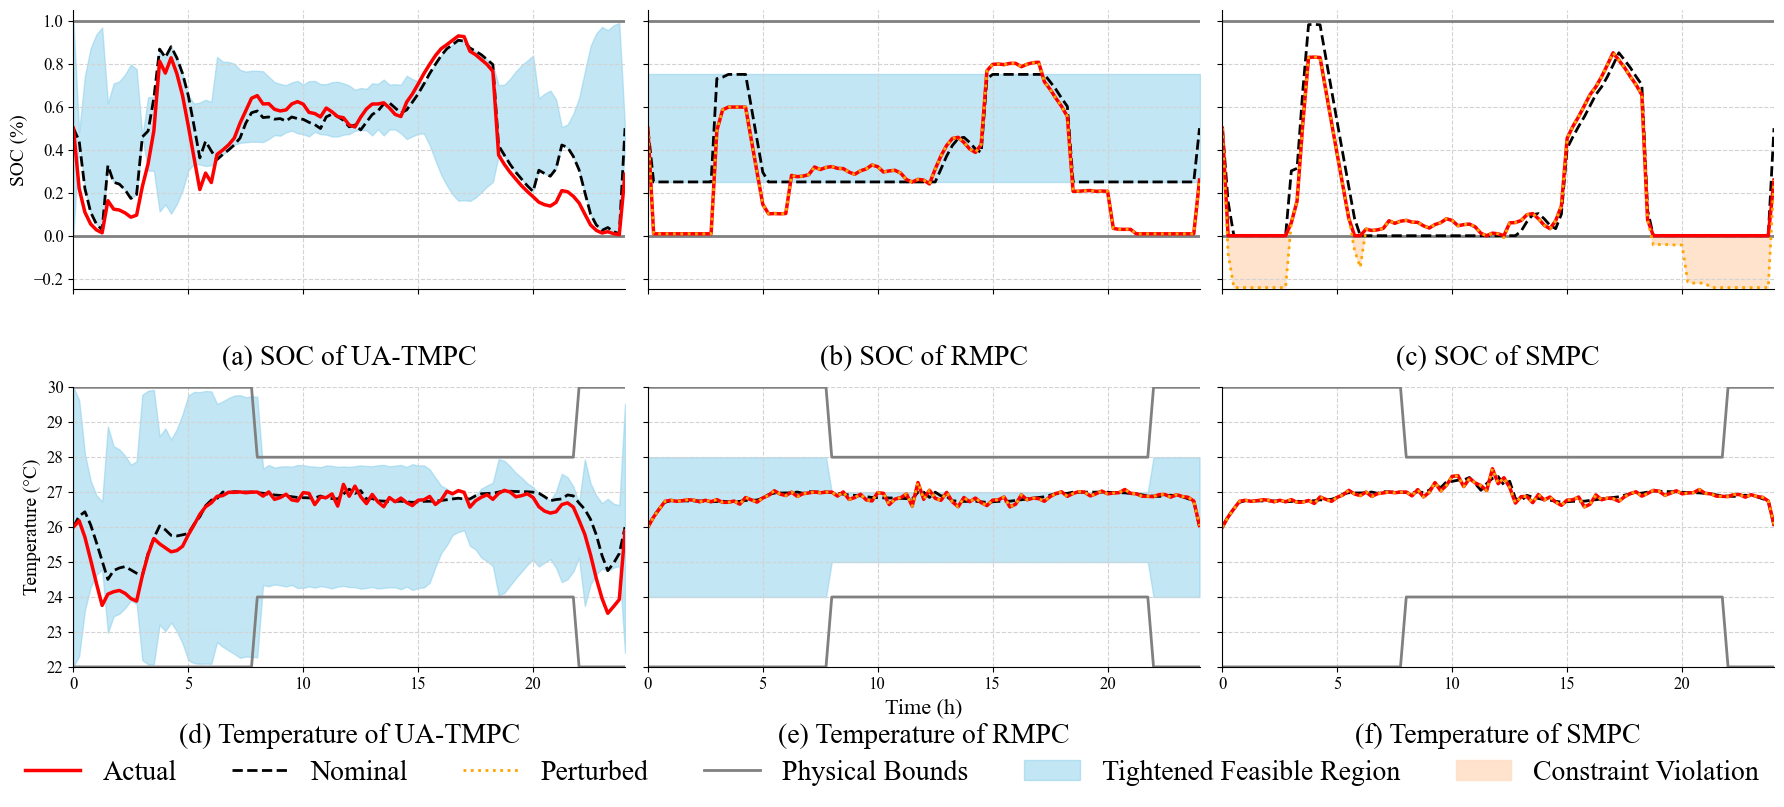

In [6]:
time_hours = np.linspace(0, 24, 97)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey='row')
# fig.suptitle('Comparison of Control Strategies', fontsize=20, y=0.98) # 总标题 (可选)

# --- 4. 定义绘图元素样式 (为了代码复用和一致性) ---
styles = {
    'actual': {'color': 'red', 'linewidth': 2.5, 'label': 'Actual'},
    'nominal': {'color': 'black', 'linestyle': '--', 'linewidth': 2.0, 'label': 'Nominal'},
    'before': {'color': 'orange', 'linestyle': ':', 'linewidth': 2.0, 'label': 'Perturbed'},
    'bounds': {'color': 'gray', 'linestyle': '-', 'linewidth': 2.0, 'label': 'Constraints'},
    'tube': {'color': 'skyblue', 'alpha': 0.5, 'label': 'Robust Tube'},
    'violation_area': {'color': '#FFDDC1', 'alpha': 0.8, 'label': 'violation area'}
}

# --- 5. 逐个绘制子图 (最清晰的方法) ---

# == Column 1: DR-TMPC (Soft_data) ==
ax_soc_dr, ax_temp_dr = axes[0, 0], axes[1, 0]
# SOC plot
ax_soc_dr.fill_between(time_hours, Soft_data['ESS Lower Tube'], Soft_data['ESS Upper Tube'], **styles['tube'])
ax_soc_dr.plot(time_hours, Soft_data['ESS Upper Bound'], **styles['bounds'])
ax_soc_dr.plot(time_hours, Soft_data['ESS Lower Bound'], **styles['bounds'])
ax_soc_dr.plot(time_hours, Soft_data['ESS nominal'], **styles['nominal'])
ax_soc_dr.plot(time_hours, Soft_data['ESS actual'], **styles['actual'])
# Temp plot
ax_temp_dr.fill_between(time_hours, Soft_data['Temp Lower Tube'], Soft_data['Temp Upper Tube'], **styles['tube'])
ax_temp_dr.plot(time_hours, Soft_data['Temp Upper Bound'], **styles['bounds'])
ax_temp_dr.plot(time_hours, Soft_data['Temp Lower Bound'], **styles['bounds'])
ax_temp_dr.plot(time_hours, Soft_data['Temp nominal'], **styles['nominal'])
ax_temp_dr.plot(time_hours, Soft_data['Temp actual'], **styles['actual'])

# # == Column 2: DMPC ==
# ax_soc_dmpc, ax_temp_dmpc = axes[0, 1], axes[1, 1]
# # SOC plot
# ax_soc_dmpc.fill_between(
#     time_hours, DMPC_data['ESS Lower Bound'], DMPC_data['ESS before'],
#     where=(DMPC_data['ESS before'] < DMPC_data['ESS Lower Bound']),
#     interpolate=True, **styles['violation_area']
# )
# ax_soc_dmpc.plot(time_hours, DMPC_data['ESS Upper Bound'], **styles['bounds'])
# ax_soc_dmpc.plot(time_hours, DMPC_data['ESS Lower Bound'], **styles['bounds'])
# ax_soc_dmpc.plot(time_hours, DMPC_data['ESS nominal'], **styles['nominal'])
# ax_soc_dmpc.plot(time_hours, DMPC_data['ESS actual'], **styles['actual'])
# ax_soc_dmpc.plot(time_hours, DMPC_data['ESS before'], **styles['before'])
# # Temp plot
# ax_temp_dmpc.plot(time_hours, DMPC_data['Temp Upper Bound'], **styles['bounds'])
# ax_temp_dmpc.plot(time_hours, DMPC_data['Temp Lower Bound'], **styles['bounds'])
# ax_temp_dmpc.plot(time_hours, DMPC_data['Temp nominal'], **styles['nominal'])
# ax_temp_dmpc.plot(time_hours, DMPC_data['Temp actual'], **styles['actual'])
# ax_temp_dmpc.plot(time_hours, DMPC_data['Temp before'], **styles['before'])

# == Column 2: RMPC ==
ax_soc_rmpc, ax_temp_rmpc = axes[0, 1], axes[1, 1]
# SOC plot
ax_soc_rmpc.fill_between(time_hours, RMPC_data['ESS Robust Lower Bound'], RMPC_data['ESS Robust Upper Bound'], **styles['tube'])
ax_soc_rmpc.fill_between(
    time_hours, RMPC_data['ESS Lower Bound'], RMPC_data['ESS before'],
    where=(RMPC_data['ESS before'] < RMPC_data['ESS Lower Bound']),
    interpolate=True, **styles['violation_area']
)
ax_soc_rmpc.plot(time_hours, RMPC_data['ESS Upper Bound'], **styles['bounds'])
ax_soc_rmpc.plot(time_hours, RMPC_data['ESS Lower Bound'], **styles['bounds'])
ax_soc_rmpc.plot(time_hours, RMPC_data['ESS nominal'], **styles['nominal'])
ax_soc_rmpc.plot(time_hours, RMPC_data['ESS actual'], **styles['actual'])
ax_soc_rmpc.plot(time_hours, RMPC_data['ESS before'], **styles['before'])
# Temp plot
ax_temp_rmpc.fill_between(time_hours, RMPC_data['Temp Robust Lower Bound'], RMPC_data['Temp Robust Upper Bound'], **styles['tube'])
ax_temp_rmpc.plot(time_hours, RMPC_data['Temp Upper Bound'], **styles['bounds'])
ax_temp_rmpc.plot(time_hours, RMPC_data['Temp Lower Bound'], **styles['bounds'])
ax_temp_rmpc.plot(time_hours, RMPC_data['Temp nominal'], **styles['nominal'])
ax_temp_rmpc.plot(time_hours, RMPC_data['Temp actual'], **styles['actual'])
ax_temp_rmpc.plot(time_hours, RMPC_data['Temp before'], **styles['before'])

# == Column 3: SMPC ==
ax_soc_smpc, ax_temp_smpc = axes[0, 2], axes[1, 2]
# SOC plot
ax_soc_smpc.fill_between(
    time_hours, SMPC_data['ESS Lower Bound'], SMPC_data['ESS before'],
    where=(SMPC_data['ESS before'] < SMPC_data['ESS Lower Bound']),
    interpolate=True, **styles['violation_area']
)
ax_soc_smpc.plot(time_hours, SMPC_data['ESS Upper Bound'], **styles['bounds'])
ax_soc_smpc.plot(time_hours, SMPC_data['ESS Lower Bound'], **styles['bounds'])
ax_soc_smpc.plot(time_hours, SMPC_data['ESS nominal'], **styles['nominal'])
ax_soc_smpc.plot(time_hours, SMPC_data['ESS actual'], **styles['actual'])
ax_soc_smpc.plot(time_hours, SMPC_data['ESS before'], **styles['before'])
# Temp plot
ax_temp_smpc.plot(time_hours, SMPC_data['Temp Upper Bound'], **styles['bounds'])
ax_temp_smpc.plot(time_hours, SMPC_data['Temp Lower Bound'], **styles['bounds'])
ax_temp_smpc.plot(time_hours, SMPC_data['Temp nominal'], **styles['nominal'])
ax_temp_smpc.plot(time_hours, SMPC_data['Temp actual'], **styles['actual'])
ax_temp_smpc.plot(time_hours, SMPC_data['Temp before'], **styles['before'])

# --- 6. 设置坐标轴、标题和网格 ---
# Column titles
axes[0, 0].set_title('(a) SOC of UA-TMPC', fontsize=20, y=-0.3)
axes[0, 1].set_title('(b) SOC of RMPC', fontsize=20, y=-0.3)
axes[0, 2].set_title('(c) SOC of SMPC', fontsize=20, y=-0.3)
axes[1, 0].set_title('(d) Temperature of UA-TMPC', fontsize=20, y=-0.3)
axes[1, 1].set_title('(e) Temperature of RMPC', fontsize=20, y=-0.3)
axes[1, 2].set_title('(f) Temperature of SMPC', fontsize=20, y=-0.3)
# Y-axis labels (only for the first column)
axes[0, 0].set_ylabel('SOC (%)')
axes[1, 0].set_ylabel('Temperature (°C)')

# 【修正】为共享 X 轴标签提供一个明确的、较高的位置
axes[1, 1].set_xlabel('Time (h)', fontsize=16)

# Universal settings for all axes
for ax in axes.flatten():
    ax.grid(True, linestyle='--', color='lightgray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 24)

# Set Y-limits consistently per row
axes[0, 0].set_ylim(-0.25, 1.05)
axes[1, 0].set_ylim(22, 30)
# fig.tight_layout()
# --- 7. 【修正】创建并精确定位底部图例 ---
handles = [
    mlines.Line2D([], [], color=styles['actual']['color'], linewidth=styles['actual']['linewidth'], label='Actual'),
    mlines.Line2D([], [], color=styles['nominal']['color'], linestyle=styles['nominal']['linestyle'], linewidth=styles['nominal']['linewidth'], label='Nominal'),
    mlines.Line2D([], [], color=styles['before']['color'], linestyle=styles['before']['linestyle'], linewidth=styles['before']['linewidth'], label='Perturbed'),
    mlines.Line2D([], [], color=styles['bounds']['color'], linestyle=styles['bounds']['linestyle'], linewidth=styles['bounds']['linewidth'], label='Physical Bounds'),
    mpatches.Patch(color=styles['tube']['color'], alpha=styles['tube']['alpha'], label='Tightened Feasible Region'),
    mpatches.Patch(color=styles['violation_area']['color'], alpha=styles['violation_area']['alpha'], label='Constraint Violation')
]

fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.04),
           ncol=6, frameon=False, fontsize=20)

fig.tight_layout()
# --- 8. 【核心修正】最终布局调整 ---
# 结合 fig.tight_layout() 和 subplots_adjust() 是最佳实践
fig.tight_layout()
fig.subplots_adjust(
    bottom=0.2,   # 减小底部边距，让整体更紧凑
    top=0.93,      # 给顶部标题留出空间
    hspace=0.35     # 增大行间距，防止标题和坐标轴重叠
)

# fig.tight_layout() 
plt.savefig(f"figures/Dynamic Behavior with robust.pdf", bbox_inches='tight')
plt.show()